
# Prediction Curve Visualization Notebook

这个 notebook 用于绘制时间序列预测结果曲线，支持两种文件格式：

## 1. 单模型结果文件

```csv
index,true,pred
0,12.3,12.1
1,13.1,13.4
2,15.6,15.0
```

## 2. 多模型合并结果文件

```csv
index,true,LSTM,Transformer,Ours
0,12.3,11.8,12.5,12.1
1,13.1,12.7,13.4,13.0
2,15.6,14.9,15.1,15.4
```

你只需要修改下面的 `CSV_PATH` 为自己的文件路径。


In [5]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.unicode_minus"] = False

# ========== 修改这里 ==========
CSV_PATH = "./draw/extreme_lstm_memo_PL72_DM64.csv"   # 改成你的 csv 文件路径
SAVE_DIR = "./figures"                    # 图片保存目录

# 如果你的横轴是 datetime，就填 "datetime"
# 如果你的横轴是 index，就填 "index"
X_COL = "index"

# 真实值列名
TRUE_COL = "true"

# 如果是 None，会自动把除 index/datetime/true 之外的列都当成模型预测列
MODEL_COLS = None

os.makedirs(SAVE_DIR, exist_ok=True)



## 1. 读取结果文件


In [6]:

df = pd.read_csv(CSV_PATH)

print("Data shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

# 如果横轴是 datetime，则转换为时间格式
if X_COL == "datetime":
    df[X_COL] = pd.to_datetime(df[X_COL])

# 自动识别模型列
if MODEL_COLS is None:
    ignore_cols = {"index", "datetime", TRUE_COL}
    MODEL_COLS = [c for c in df.columns if c not in ignore_cols]

print("X column:", X_COL)
print("True column:", TRUE_COL)
print("Model columns:", MODEL_COLS)

assert X_COL in df.columns, f"找不到横轴列: {X_COL}"
assert TRUE_COL in df.columns, f"找不到真实值列: {TRUE_COL}"
assert len(MODEL_COLS) > 0, "没有找到模型预测列"
for col in MODEL_COLS:
    assert col in df.columns, f"找不到模型预测列: {col}"


Data shape: (8640, 3)
Columns: ['index', 'true', 'pred']


,index,true,pred
0,0,1239.5197,1239.4540
1,1,1239.5197,1238.8953
2,2,1239.5197,1239.0153
3,3,1239.5197,1239.1190
4,4,1239.5197,1238.6553


X column: index
True column: true
Model columns: ['pred']



## 2. 绘制完整测试集预测曲线

如果点数很多，完整曲线可能比较密集。完整图适合看整体趋势，局部图适合看模型差异。


In [7]:

def plot_prediction_curve(
    df,
    x_col,
    true_col,
    model_cols,
    start=None,
    end=None,
    title="Prediction Curve",
    save_name=None,
):
    # 绘制真实值和一个或多个模型预测值曲线。
    # start/end:
    #   如果为 None，则画完整序列；
    #   如果指定，则画 df.iloc[start:end] 这一段。
    if start is not None or end is not None:
        data = df.iloc[start:end].copy()
        range_text = f"[{start}:{end}]"
    else:
        data = df.copy()
        range_text = "Full Test Set"

    plt.figure(figsize=(14, 5))

    plt.plot(
        data[x_col],
        data[true_col],
        label="Ground Truth",
        linewidth=2.2,
        alpha=0.95,
    )

    for col in model_cols:
        plt.plot(
            data[x_col],
            data[col],
            label=col,
            linewidth=1.4,
            alpha=0.85,
        )

    plt.xlabel(x_col)
    plt.ylabel("Value")
    plt.title(f"{title} - {range_text}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()

    if save_name is not None:
        save_path = os.path.join(SAVE_DIR, save_name)
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()


Saved: ./figures/full_prediction_curve.png


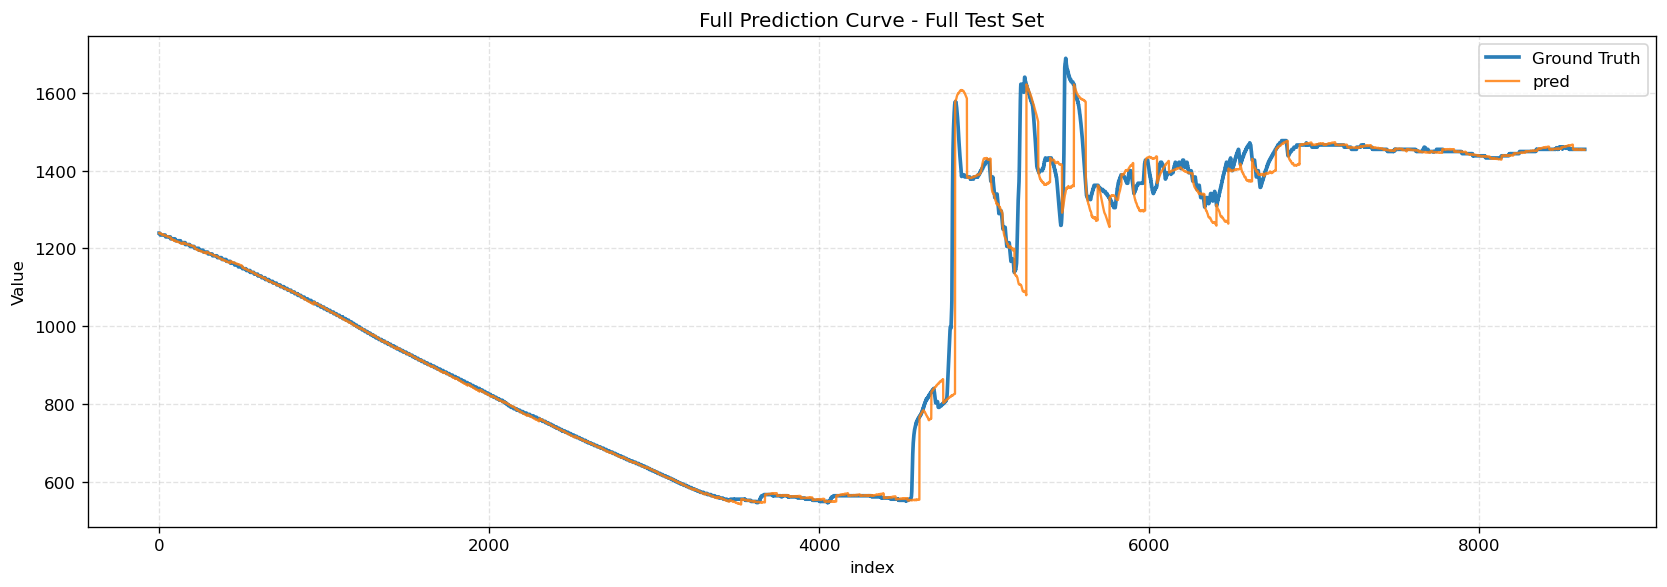

In [8]:

plot_prediction_curve(
    df=df,
    x_col=X_COL,
    true_col=TRUE_COL,
    model_cols=MODEL_COLS,
    title="Full Prediction Curve",
    save_name="full_prediction_curve.png",
)



## 3. 绘制局部放大图

论文或报告里更推荐放局部图，因为完整测试集太长时，不同模型的差异会被压缩。


Saved: ./figures/zoom_prediction_curve_0_500.png


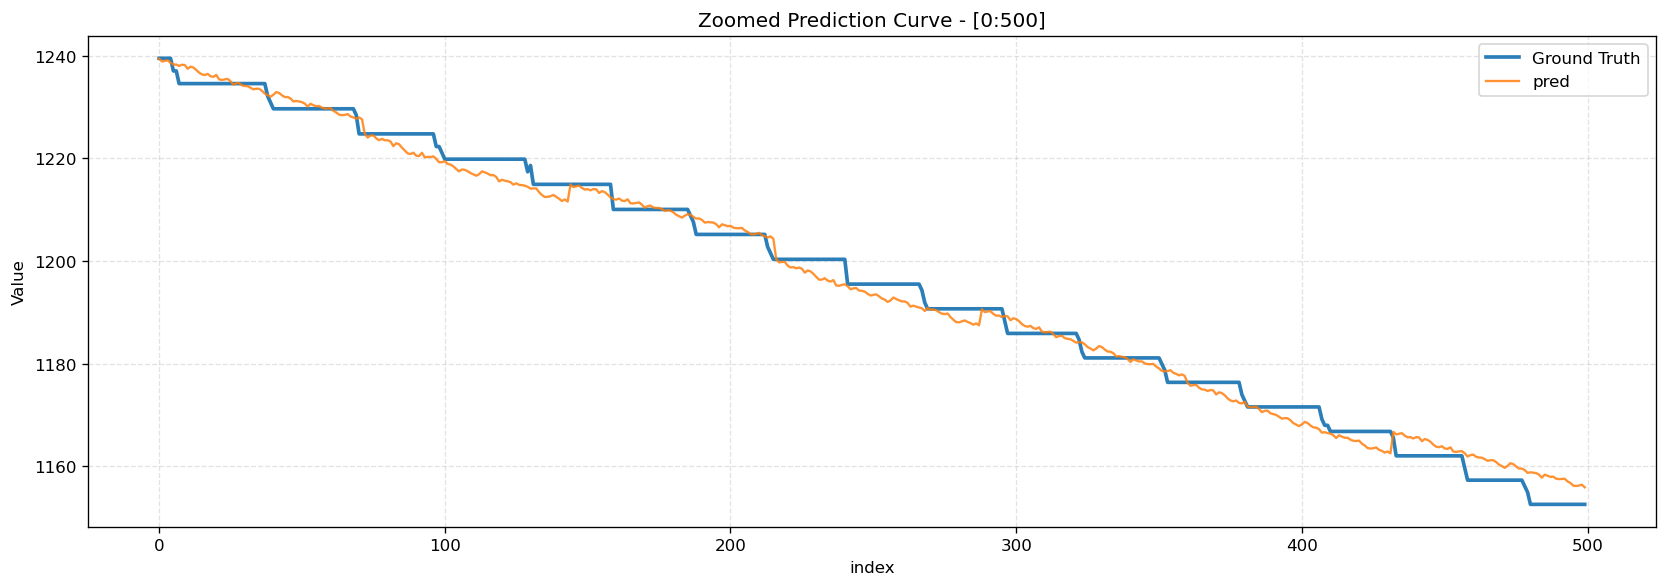

In [9]:

# ========== 修改这里 ==========
START = 0
END = min(500, len(df))

plot_prediction_curve(
    df=df,
    x_col=X_COL,
    true_col=TRUE_COL,
    model_cols=MODEL_COLS,
    start=START,
    end=END,
    title="Zoomed Prediction Curve",
    save_name=f"zoom_prediction_curve_{START}_{END}.png",
)



## 4. 绘制误差曲线

误差曲线可以显示模型在哪些时间点偏差更大。

这里画的是：

```text
error = prediction - true
```


In [10]:

def plot_error_curve(
    df,
    x_col,
    true_col,
    model_cols,
    start=None,
    end=None,
    save_name=None,
):
    if start is not None or end is not None:
        data = df.iloc[start:end].copy()
        range_text = f"[{start}:{end}]"
    else:
        data = df.copy()
        range_text = "Full Test Set"

    plt.figure(figsize=(14, 4))

    for col in model_cols:
        error = data[col] - data[true_col]
        plt.plot(
            data[x_col],
            error,
            label=f"{col} error",
            linewidth=1.2,
            alpha=0.85,
        )

    plt.axhline(0, linewidth=1.0)
    plt.xlabel(x_col)
    plt.ylabel("Prediction Error")
    plt.title(f"Error Curve - {range_text}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()

    if save_name is not None:
        save_path = os.path.join(SAVE_DIR, save_name)
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()


Saved: ./figures/error_curve_0_500.png


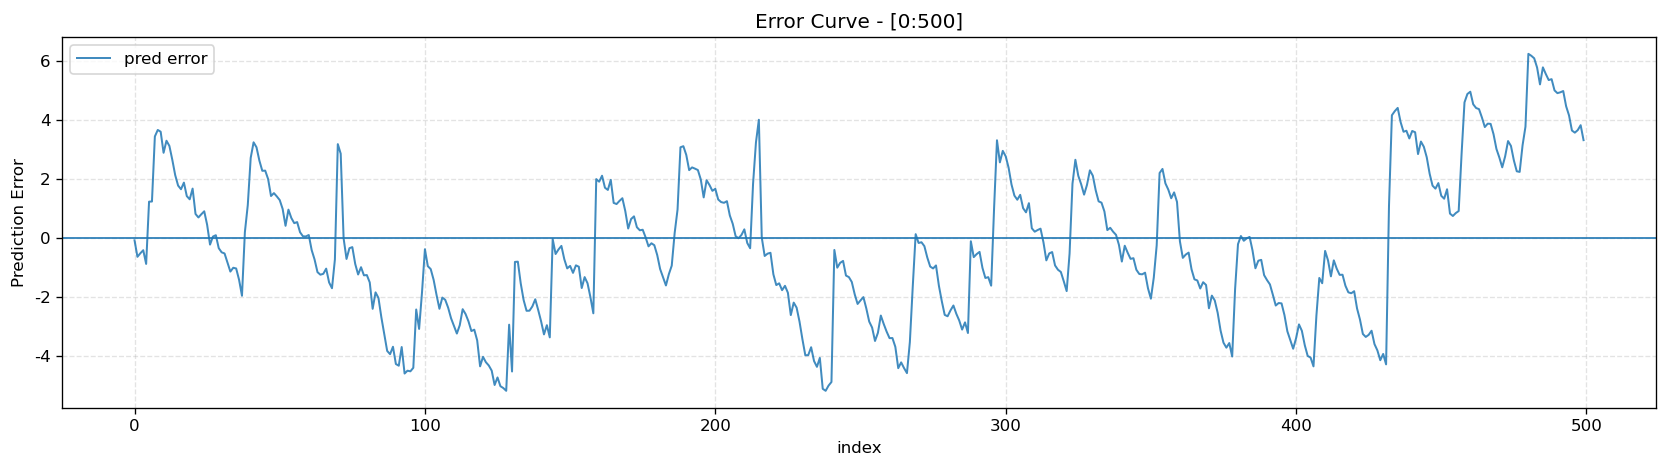

In [11]:

plot_error_curve(
    df=df,
    x_col=X_COL,
    true_col=TRUE_COL,
    model_cols=MODEL_COLS,
    start=START,
    end=END,
    save_name=f"error_curve_{START}_{END}.png",
)



## 5. 绘制极端点区域图

如果你的目标是观察极端值预测效果，可以用训练集分位数阈值，比如 q90 / q95 / q99。

如果你已经知道训练集阈值，可以手动填入 `EXTREME_THRESHOLD`。
如果暂时没有训练集阈值，也可以先用当前测试真实值的 q90 临时观察，但论文指标最好使用训练集阈值。


In [12]:

# ========== 修改这里 ==========
# 推荐填训练集统计得到的 q90 / q95 / q99 阈值
EXTREME_THRESHOLD = None

if EXTREME_THRESHOLD is None:
    EXTREME_THRESHOLD = df[TRUE_COL].quantile(0.90)
    print("Using test-set q90 as temporary threshold:", EXTREME_THRESHOLD)
else:
    print("Using given threshold:", EXTREME_THRESHOLD)


Using test-set q90 as temporary threshold: 1456.4869


In [13]:

def plot_extreme_region(
    df,
    x_col,
    true_col,
    model_cols,
    threshold,
    start=None,
    end=None,
    save_name=None,
):
    if start is not None or end is not None:
        data = df.iloc[start:end].copy()
        range_text = f"[{start}:{end}]"
    else:
        data = df.copy()
        range_text = "Full Test Set"

    plt.figure(figsize=(14, 5))

    plt.plot(
        data[x_col],
        data[true_col],
        label="Ground Truth",
        linewidth=2.2,
        alpha=0.95,
    )

    for col in model_cols:
        plt.plot(
            data[x_col],
            data[col],
            label=col,
            linewidth=1.4,
            alpha=0.85,
        )

    plt.axhline(
        threshold,
        linestyle="--",
        linewidth=1.2,
        label=f"Extreme threshold = {threshold:.4f}",
    )

    extreme_mask = data[true_col] >= threshold
    if extreme_mask.any():
        plt.scatter(
            data.loc[extreme_mask, x_col],
            data.loc[extreme_mask, true_col],
            s=18,
            label="True extreme points",
            zorder=5,
        )

    plt.xlabel(x_col)
    plt.ylabel("Value")
    plt.title(f"Extreme Region Prediction - {range_text}")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()

    if save_name is not None:
        save_path = os.path.join(SAVE_DIR, save_name)
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()


Saved: ./figures/extreme_region_0_500.png


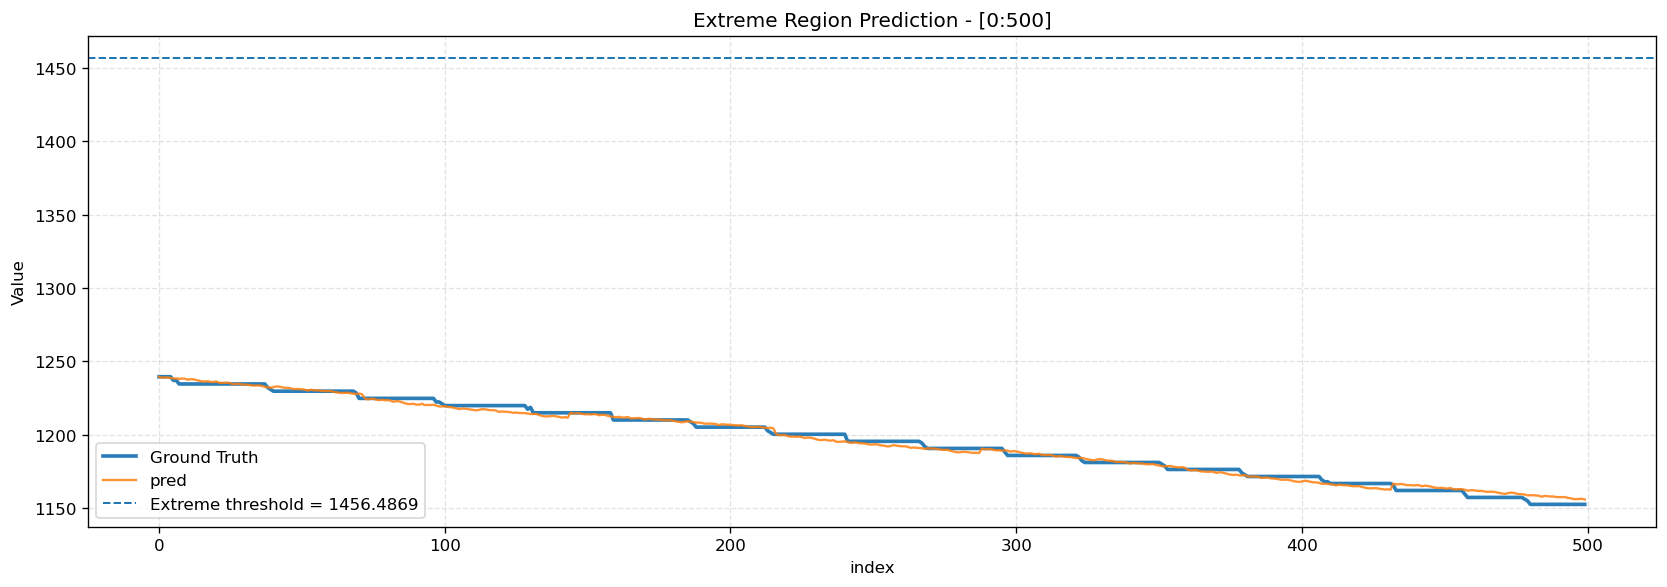

In [14]:

plot_extreme_region(
    df=df,
    x_col=X_COL,
    true_col=TRUE_COL,
    model_cols=MODEL_COLS,
    threshold=EXTREME_THRESHOLD,
    start=START,
    end=END,
    save_name=f"extreme_region_{START}_{END}.png",
)



## 6. 计算并展示简单误差指标

这里给出 MAE、MSE、RMSE、MAPE，方便确认曲线和数值指标是否一致。


In [15]:

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_pred - y_true))
    mse = np.mean((y_pred - y_true) ** 2)
    rmse = np.sqrt(mse)

    eps = 1e-8
    mape = np.mean(np.abs((y_pred - y_true) / (np.abs(y_true) + eps))) * 100

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE(%)": mape,
    }

metric_rows = []
for col in MODEL_COLS:
    metrics = calc_metrics(df[TRUE_COL].values, df[col].values)
    metrics["Model"] = col
    metric_rows.append(metrics)

metric_df = pd.DataFrame(metric_rows)
metric_df = metric_df[["Model", "MAE", "MSE", "RMSE", "MAPE(%)"]]
display(metric_df)

metric_save_path = os.path.join(SAVE_DIR, "metrics.csv")
metric_df.to_csv(metric_save_path, index=False)
print("Saved:", metric_save_path)


,Model,MAE,MSE,RMSE,MAPE(%)
0,pred,18.495047,3888.652893,62.359064,1.460516


Saved: ./figures/metrics.csv



## 7. 如果你现在是多个单模型文件，而不是合并文件

假设你现在有：

```text
./results/LSTM_PL72.csv
./results/Transformer_PL72.csv
./results/Ours_PL72.csv
```

每个文件都是：

```csv
index,true,pred
```

可以用下面这段代码合并成：

```csv
index,true,LSTM,Transformer,Ours
```


In [16]:

def merge_single_model_csvs(model_csv_dict, save_path):
    # model_csv_dict 示例：
    # {
    #     "LSTM": "./results/LSTM_PL72.csv",
    #     "Transformer": "./results/Transformer_PL72.csv",
    #     "Ours": "./results/Ours_PL72.csv",
    # }
    merged_df = None

    for model_name, csv_path in model_csv_dict.items():
        temp = pd.read_csv(csv_path)

        assert "index" in temp.columns, f"{csv_path} 缺少 index 列"
        assert "true" in temp.columns, f"{csv_path} 缺少 true 列"
        assert "pred" in temp.columns, f"{csv_path} 缺少 pred 列"

        temp = temp[["index", "true", "pred"]].copy()
        temp = temp.rename(columns={"pred": model_name})

        if merged_df is None:
            merged_df = temp
        else:
            temp = temp[["index", model_name]]
            merged_df = pd.merge(merged_df, temp, on="index", how="inner")

    merged_df.to_csv(save_path, index=False)
    print("Saved merged result:", save_path)
    return merged_df


# 使用示例：
# model_csv_dict = {
#     "LSTM": "./results/LSTM_PL72.csv",
#     "Transformer": "./results/Transformer_PL72.csv",
#     "Ours": "./results/Ours_PL72.csv",
# }
#
# merged_df = merge_single_model_csvs(
#     model_csv_dict=model_csv_dict,
#     save_path="./results/compare_PL72.csv",
# )
#
# display(merged_df.head())



## 8. 论文图建议

一般论文里不要直接放完整测试集超长曲线。更推荐：

1. 放一张局部区间预测图，比如 `index=1000~1500`
2. 放真实值、Baseline、Ours 三条左右，不要放太多模型
3. 如果强调极端值预测，放带阈值线和极端点标记的局部图
4. 完整测试集曲线可以放附录或补充材料
